In [ ]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 1.7 MB/s eta 0:00:00


In [ ]:
from kan import KAN
import kan.utils

In [ ]:
import torch

In [ ]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [ ]:
data = load_breast_cancer()

In [ ]:
X = data.data
y = data.target
feature_names = data.feature_names

In [ ]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

In [ ]:
shuffled = df.sample(frac=1, random_state=17).reset_index(drop=True)


In [ ]:
train_end = int(.8 * len(df))
valid_end =len(df)

train = shuffled.iloc[:train_end]
valid = shuffled.iloc[train_end:valid_end]

In [ ]:
def scale_dataset(dataframe, oversample=False):
    x = dataframe[dataframe.columns[:-1]].values
    y = dataframe[dataframe.columns[-1]].values

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)

    if oversample:
        ros = RandomOverSampler(random_state=17)
        x_scaled, y = ros.fit_resample(x_scaled, y)

    data  = np.hstack((x_scaled, y.reshape(-1, 1)))
    return x_scaled, y, data


In [ ]:
x_train, y_train, train = scale_dataset(train, oversample=True)
x_valid, y_valid, valid = scale_dataset(valid, oversample=False)

In [ ]:
x_train = torch.tensor(x_train)
y_train = torch.tensor(y_train)
x_valid = torch.tensor(x_valid)
y_valid = torch.tensor(y_valid)

/tmp/ipykernel_443/544124071.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train)


In [ ]:
dataset = {

         "train_input" : x_train,
         "train_label" : y_train,
         "test_input" : x_valid,
         "test_label" : y_valid
}

In [ ]:
dataset['train_input'] = torch.tensor(x_train, dtype=torch.float32)
dataset['train_label'] = torch.tensor(y_train, dtype=torch.float32)
dataset['test_input'] = torch.tensor(x_valid, dtype=torch.float32)
dataset['test_label'] = torch.tensor(y_valid, dtype=torch.float32)


/tmp/ipykernel_443/3968882738.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset['train_input'] = torch.tensor(x_train, dtype=torch.float32)
/tmp/ipykernel_443/3968882738.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset['train_label'] = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_443/3968882738.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset['test_input'] = torch.tensor(x_valid, dtype=torch.float32)
/tmp/ipykernel_443/3968882738.py:4: UserWarning: To copy construct from a tensor, it is recomme

In [ ]:
model = kan.KAN(width = [30,7,5,1], grid = 7, k = 3)

checkpoint directory created: ./model
saving model version 0.0


In [ ]:
model.fit(dataset,opt = 'LBFGS', steps = 150,lr = 1.5, lamb = 0.00001,lamb_entropy =8.209 )


description:   0%|                                                          | 0/150 [00:00<?, ?it/s]
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 6.96e+01 | :   0%|      | 0/150 [00:00<?, ?it/s]
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 6.96e+01 | :   1%| | 1/150 [00:00<01:42,  1.46it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 5.41e+01 | :   1%| | 1/150 [00:01<01:42,  1.46it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 5.41e+01 | :   1%| | 2/150 [00:01<01:32,  1.59it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 3.80e+01 | :   1%| | 2/150 [00:01<01:32,  1.59it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 3.80e+01 | :   2%| | 3/150 [00:01<01:26,  1.70it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 1.96e+01 | :   2%| | 3/150 [00:02<01:26,  1.70it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 1.96e+01 | :   3%| | 4/150 [00:02<01:27,  1.66it
| train_loss: 5.00e-01 | test_loss: 5.00e-01 | reg: 1.13e+01 | :   3%| | 4/150 [00:03<01:2

saving model version 0.1


{'train_loss': [array(0.50000685, dtype=float32),
  array(0.5000031, dtype=float32),
  array(0.50000095, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.5, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.5, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=float32),
  array(0.50000006, dtype=flo

description:   0%|                                                          | 0/150 [14:17<?, ?it/s]


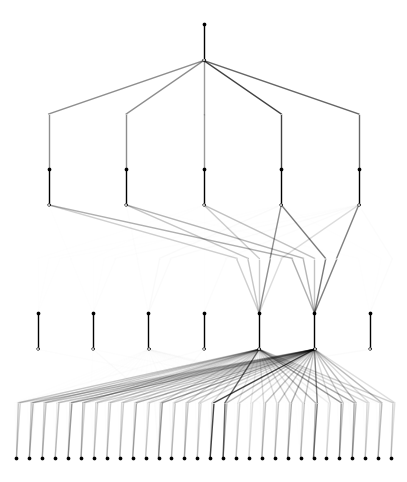

In [ ]:
model.plot()

In [ ]:
model = model.prune()

saving model version 0.2


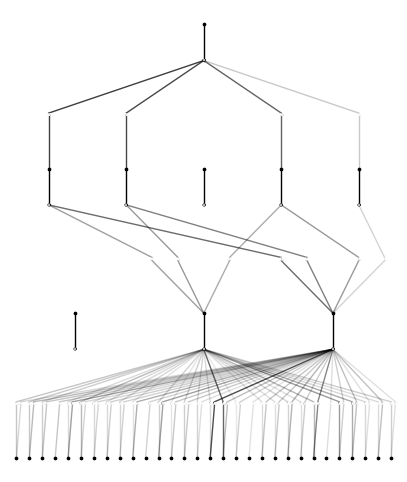

In [ ]:
model.plot()

In [ ]:
x_valid = x_valid.float()
y_valid = y_valid.float()

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
with torch.no_grad():
  y_spline_s = model(x_valid)
r2_spline = r2_score(y_valid.numpy(),y_spline_s.numpy())


In [ ]:
print(y_spline_s.min(), y_spline_s.max())

tensor(6.6322e-05) tensor(0.0208)


In [ ]:
y_pred = (torch.sigmoid(y_spline_s) > 0.5).float()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
accuracy_score(y_valid,y_pred)

0.5964912280701754

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_valid.numpy(), y_pred.numpy()))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        46
         1.0       0.60      1.00      0.75        68

    accuracy                           0.60       114
   macro avg       0.30      0.50      0.37       114
weighted avg       0.36      0.60      0.45       114



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


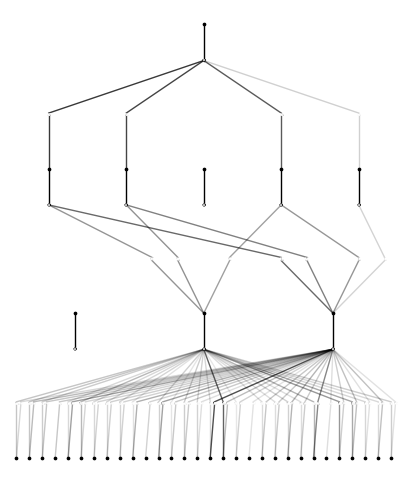

In [ ]:
model.plot()